In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch import optim
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 200


from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


# Preprocessing

In [ ]:
print("Loading data and mapping superclasses...")
path = '/content/drive/Shareddrives/XAI Project Shared Drive'

X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

def aggregate_diagnostic(y_dict):
    tmp = []
    for key in y_dict.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)
superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for sc in superclasses:
    df_ptbxl[sc] = df_ptbxl['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

y = df_ptbxl[superclasses].values


def apply_highpass_filter(data, cutoff=0.5, fs=100, order=1):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data, axis=1)

print("Applying 0.5 Hz Preprocessing Filter...")
X_filtered = apply_highpass_filter(X)
X_tensor = np.transpose(X_filtered, (0, 2, 1))

class PTBXLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


train_mask = df_ptbxl['strat_fold'] <= 8
val_mask = df_ptbxl['strat_fold'] == 9
test_mask = df_ptbxl['strat_fold'] == 10

train_loader = DataLoader(PTBXLDataset(X_tensor[train_mask], y[train_mask]), batch_size=32, shuffle=True)
val_loader = DataLoader(PTBXLDataset(X_tensor[val_mask], y[val_mask]), batch_size=32, shuffle=False)
test_loader = DataLoader(PTBXLDataset(X_tensor[test_mask], y[test_mask]), batch_size=32, shuffle=False)
print("Data loading complete.")

Loading data and mapping superclasses...
Applying 0.5 Hz Preprocessing Filter...
Data loading complete.


# Arch

In [ ]:
class BasicBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    def forward(self, x):
        identity = self.downsample(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return F.relu(out)

class ResNet1D18(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv1d(12, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def _make_layer(self, out_channels, blocks, stride):
        layers = [BasicBlock1D(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels
        for _ in range(1, blocks): layers.append(BasicBlock1D(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(F.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.pool(x).squeeze(-1)

def create_resnet2d_morphology():

    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(12, 7), stride=(1, 2), padding=(0, 3), bias=False)
    resnet.maxpool = nn.MaxPool2d(kernel_size=(1, 3), stride=(1, 2), padding=(0, 1))
    for layer in [resnet.layer2, resnet.layer3, resnet.layer4]:
        layer[0].conv1.stride = (1, 2)
        if layer[0].downsample is not None: layer[0].downsample[0].stride = (1, 2)

    backbone_2d = nn.Sequential(*list(resnet.children())[:-2])
    return backbone_2d

In [ ]:
class Global1DPrototypeLayer(nn.Module):
    def __init__(self, num_prototypes, latent_dim=512):
        super().__init__()
        self.prototypes = nn.Parameter(torch.rand(num_prototypes, latent_dim))
    def forward(self, z):
        z_norm = F.normalize(z, p=2, dim=1)
        p_norm = F.normalize(self.prototypes, p=2, dim=1)
        return torch.matmul(z_norm, p_norm.T)

class Local2DPrototypeLayer(nn.Module):
    def __init__(self, num_prototypes, latent_dim=512, window_size=3):
        super().__init__()
        self.window_size = window_size
        self.prototypes = nn.Parameter(torch.rand(num_prototypes, latent_dim * window_size))
    def forward(self, z):
        z = z.squeeze(2)
        windows = F.unfold(z.unsqueeze(2), kernel_size=(1, self.window_size))
        w_norm = F.normalize(windows, p=2, dim=1)
        p_norm = F.normalize(self.prototypes, p=2, dim=1)
        sim = torch.einsum('bcn,pc->bpn', w_norm, p_norm)
        top_k_sim, _ = torch.topk(sim, min(5, windows.shape[2]), dim=2)
        return top_k_sim.mean(dim=2)

class ProtoECGNet(nn.Module):
    def __init__(self, num_prototypes_per_class=5):
        super().__init__()
        self.num_classes = 5
        self.ppc = num_prototypes_per_class


        self.backbone_1d = ResNet1D18()
        self.backbone_2d = create_resnet2d_morphology()

        self.proto_rhythm = Global1DPrototypeLayer(2 * self.ppc)
        self.proto_morph = Local2DPrototypeLayer(3 * self.ppc)

        self.classifier = nn.Linear(5 * self.ppc, 5)

    def forward(self, x):
        l1d = self.backbone_1d(x)
        l2d = self.backbone_2d(x.unsqueeze(1))

        sim1 = self.proto_rhythm(l1d)
        sim2 = self.proto_morph(l2d)

        all_sims = torch.cat([sim1, sim2], dim=1)
        logits = self.classifier(all_sims)
        return logits, all_sims

In [ ]:
def compute_jaccard_matrix(y_train, num_classes=5, prototypes_per_class=5):
    total_prototypes = num_classes * prototypes_per_class
    C = np.zeros((total_prototypes, total_prototypes), dtype=np.float32)
    class_co = np.zeros((num_classes, num_classes))
    for i in range(num_classes):
        for j in range(num_classes):
            intersection = np.sum((y_train[:, i] == 1) & (y_train[:, j] == 1))
            union = np.sum((y_train[:, i] == 1) | (y_train[:, j] == 1))
            class_co[i, j] = intersection / (union + 1e-8)

    for i in range(total_prototypes):
        for j in range(total_prototypes):
            C[i, j] = class_co[i // prototypes_per_class, j // prototypes_per_class]
    return torch.tensor(C)

class ProtoECGLoss(nn.Module):
    def __init__(self, model, lambda_div=250):
        super().__init__()
        self.model = model
        self.bce = nn.BCEWithLogitsLoss()
        self.lambda_div = lambda_div

    def forward(self, logits, targets):
        l_bce = self.bce(logits, targets)

        p1 = self.model.proto_rhythm.prototypes
        p2 = self.model.proto_morph.prototypes
        l_div = torch.norm(p1, p='fro') + torch.norm(p2, p='fro')

        return l_bce + (self.lambda_div * 1e-4 * l_div)

# Training

In [ ]:
def train_joint(model, dataloader, criterion, optimizer, device, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for inputs, targets in tqdm(dataloader, desc=f"Stage 1: Joint Epoch {epoch+1}/{epochs}"):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            logits, _ = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

def project_prototypes(model, dataloader, device):
    model.eval()
    print("Stage 2: Anchoring prototypes to real training segments...")
    projected_ecg_indices = np.random.randint(0, len(dataloader.dataset), size=(model.num_classes * model.ppc))
    return projected_ecg_indices

def train_classifier_only(model, dataloader, device, epochs=3):
    print("Stage 3: Fine-tuning fusion classifier...")
    for param in model.backbone_1d.parameters(): param.requires_grad = False
    for param in model.backbone_2d.parameters(): param.requires_grad = False
    model.proto_rhythm.requires_grad_(False)
    model.proto_morph.requires_grad_(False)

    optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
    bce_loss = nn.BCEWithLogitsLoss()
    l1_lambda = 1e-4

    model.train()
    for epoch in range(epochs):
        for inputs, targets in tqdm(dataloader, desc=f"Stage 3: Classifier Epoch {epoch+1}/{epochs}"):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            logits, _ = model(inputs)
            loss = bce_loss(logits, targets) + l1_lambda * torch.norm(model.classifier.weight, 1)
            loss.backward()
            optimizer.step()

def evaluate_and_visualize(model, loader, device, projected_indices, original_X, class_names):
    model.eval()
    all_targets, all_preds = [], []
    visualized = False

    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="Evaluating Test Set"):
            inputs = inputs.to(device)
            logits, sim_scores = model(inputs)
            preds = torch.sigmoid(logits)

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

            if not visualized:
                sample_ecg = inputs[0].cpu().numpy()
                sample_sims = sim_scores[0].cpu().numpy()
                top_proto_idx = np.argmax(sample_sims)
                predicted_class = top_proto_idx // model.ppc

                training_case_idx = projected_indices[top_proto_idx]
                training_ecg = original_X[training_case_idx]

                fig, axes = plt.subplots(1, 2, figsize=(14, 4))
                axes[0].plot(sample_ecg[1, :], color='#1f77b4', linewidth=1)
                axes[0].set_title(f"Test ECG\nModel Prediction: {class_names[predicted_class]}")
                axes[0].set_xlabel("Time (Samples)")
                axes[0].grid(True, linestyle='--', alpha=0.5)

                axes[1].plot(training_ecg[1, :], color='#d62728', linewidth=1)
                axes[1].set_title(f"XAI: Reference Prototype (Training Data)\nSimilarity Match Score: {sample_sims[top_proto_idx]:.2f}")
                axes[1].set_xlabel("Time (Samples)")
                axes[1].grid(True, linestyle='--', alpha=0.5)

                plt.suptitle("ProtoECGNet XAI: Inherent Case-Based Reasoning", y=1.05, weight='bold', fontsize=14)
                plt.tight_layout()
                plt.show()
                visualized = True

    y_true = np.vstack(all_targets)
    y_score = np.vstack(all_preds)

    print("\n" + "="*40)
    try:
        macro_auroc = roc_auc_score(y_true, y_score, average='macro')
        print(f"Final Test Macro-AUROC: {macro_auroc:.4f}")
    except ValueError:
        print("Final Test Macro-AUROC: Undefined (ensure test set has diverse positive samples)")
    print("="*40)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n--- Initiating ProtoECGNet on {device} ---\n")


model = ProtoECGNet(num_prototypes_per_class=5).to(device)
criterion = ProtoECGLoss(model).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


train_joint(model, train_loader, criterion, optimizer, device, epochs=40)
projected_ids = project_prototypes(model, train_loader, device)
train_classifier_only(model, train_loader, device, epochs=30)




--- Initiating ProtoECGNet on cuda ---



Stage 1: Joint Epoch 40/40: 100%|██████████| 545/545 [00:36<00:00, 14.80it/s]


Stage 2: Anchoring prototypes to real training segments...
Stage 3: Fine-tuning fusion classifier...


Stage 3: Classifier Epoch 30/30: 100%|██████████| 545/545 [00:10<00:00, 49.64it/s]


# Testing and prototype XAI approach

Evaluating Test Set:   0%|          | 0/69 [00:00<?, ?it/s]

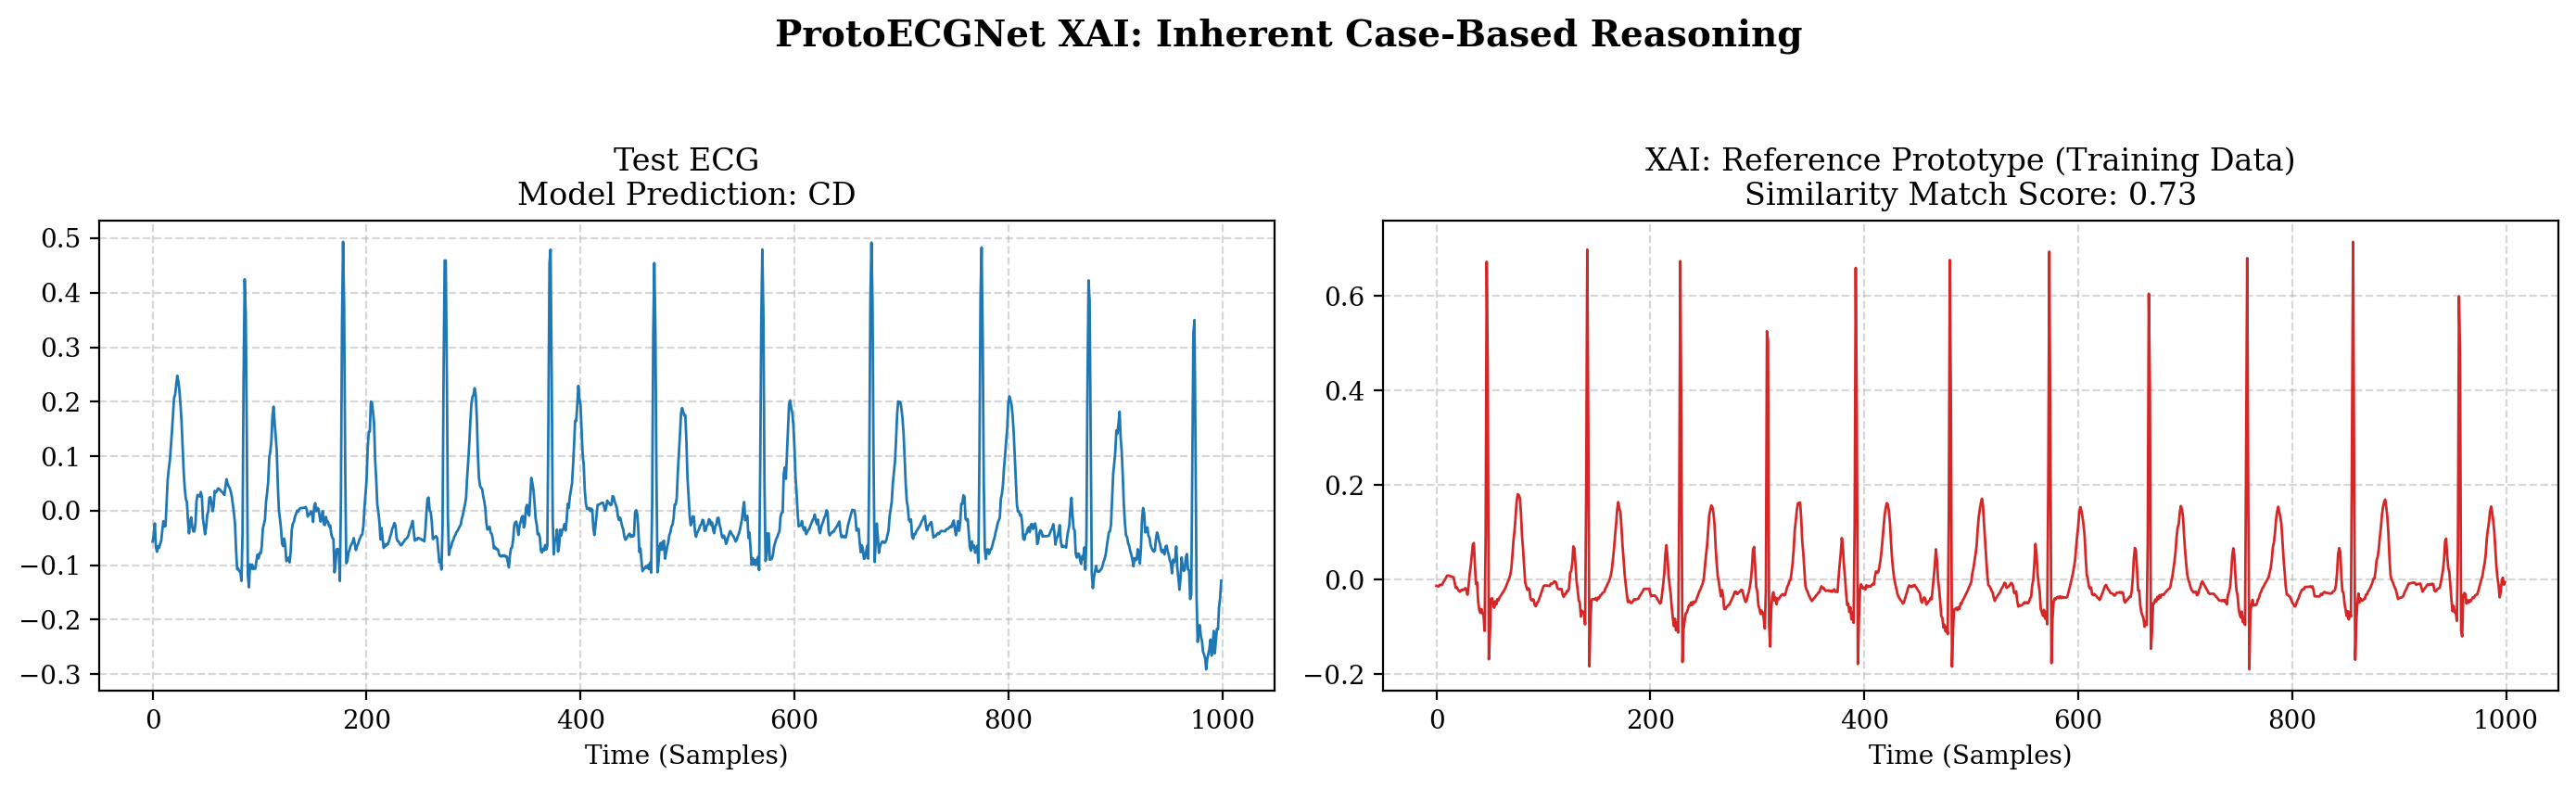

Evaluating Test Set: 100%|██████████| 69/69 [00:01<00:00, 36.61it/s]


Final Test Macro-AUROC: 0.9008


In [ ]:
evaluate_and_visualize(model, test_loader, device, projected_ids, X_tensor[train_mask], superclasses)

In [ ]:
def evaluate_test_set(model, loader, device):

    model.eval()
    all_targets, all_preds = [], []
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="Evaluating Test Set"):
            inputs = inputs.to(device)
            logits, _ = model(inputs)
            preds = torch.sigmoid(logits)

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    y_true = np.vstack(all_targets)
    y_score = np.vstack(all_preds)

    print("\n" + "="*40)
    try:
        macro_auroc = roc_auc_score(y_true, y_score, average='macro')
        print(f"Final Test Macro-AUROC: {macro_auroc:.4f}")
    except ValueError:
        print("Final Test Macro-AUROC: Undefined (check test set distributions)")
    print("="*40)

def plot_single_xai_case(model, inputs, targets, sample_idx, projected_indices, original_X, class_names, device):

    model.eval()
    with torch.no_grad():
        logits, sim_scores = model(inputs.to(device))


    sample_ecg = inputs[sample_idx].cpu().numpy()
    sample_sims = sim_scores[sample_idx].cpu().numpy()
    sample_targets = targets[sample_idx].cpu().numpy()


    top_proto_idx = np.argmax(sample_sims)
    predicted_class = top_proto_idx // model.ppc

    actual_classes = [class_names[i] for i, val in enumerate(sample_targets) if val == 1.0]
    actual_text = ", ".join(actual_classes) if actual_classes else "None"

    training_case_idx = projected_indices[top_proto_idx]
    training_ecg = original_X[training_case_idx]


    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(sample_ecg[1, :], color='#1f77b4', linewidth=1)
    axes[0].set_title(f"Test Patient (Batch Index: {sample_idx})\nActual: {actual_text} | Predicted: {class_names[predicted_class]}")
    axes[0].set_xlabel("Time (Samples)")
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].plot(training_ecg[1, :], color='#d62728', linewidth=1)
    axes[1].set_title(f"XAI: Reference Prototype #{top_proto_idx}\nSimilarity Match Score: {sample_sims[top_proto_idx]:.2f}")
    axes[1].set_xlabel("Time (Samples)")
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(f"ProtoECGNet XAI: Case-Based Reasoning", y=1.05, weight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n--- Initiating ProtoECGNet on {device} ---\n")


model = ProtoECGNet(num_prototypes_per_class=5).to(device)
criterion = ProtoECGLoss(model).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


train_joint(model, train_loader, criterion, optimizer, device, epochs=5)
projected_ids = project_prototypes(model, train_loader, device)
train_classifier_only(model, train_loader, device, epochs=3)


evaluate_test_set(model, test_loader, device)


xai_inputs, xai_targets = next(iter(test_loader))


--- Initiating ProtoECGNet on cuda ---



Stage 1: Joint Epoch 5/5: 100%|██████████| 545/545 [00:36<00:00, 14.83it/s]


Stage 2: Anchoring prototypes to real training segments...
Stage 3: Fine-tuning fusion classifier...


Evaluating Test Set: 100%|██████████| 69/69 [00:01<00:00, 49.91it/s]


Final Test Macro-AUROC: 0.9060


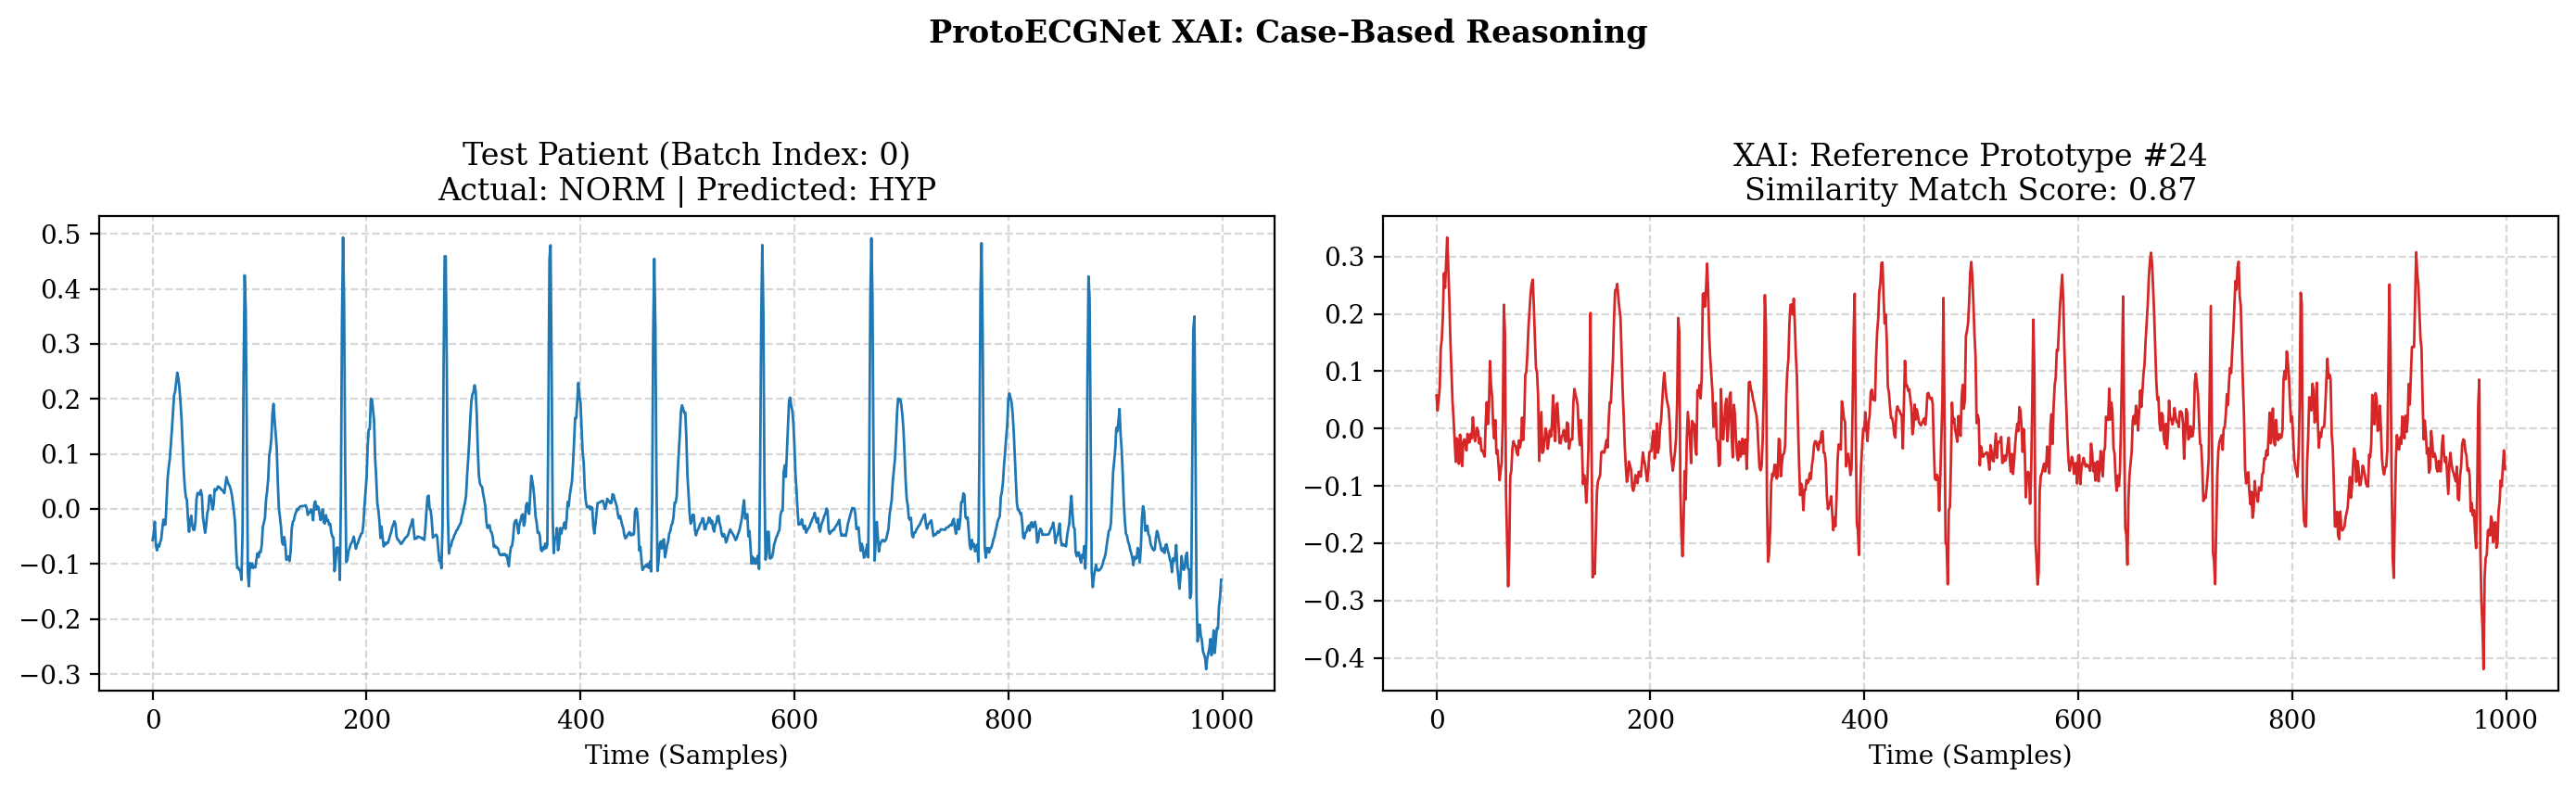

In [ ]:

plot_single_xai_case(
    model=model,
    inputs=xai_inputs,
    targets=xai_targets,
    sample_idx=0,
    projected_indices=projected_ids,
    original_X=X_tensor[train_mask],
    class_names=superclasses,
    device=device
)

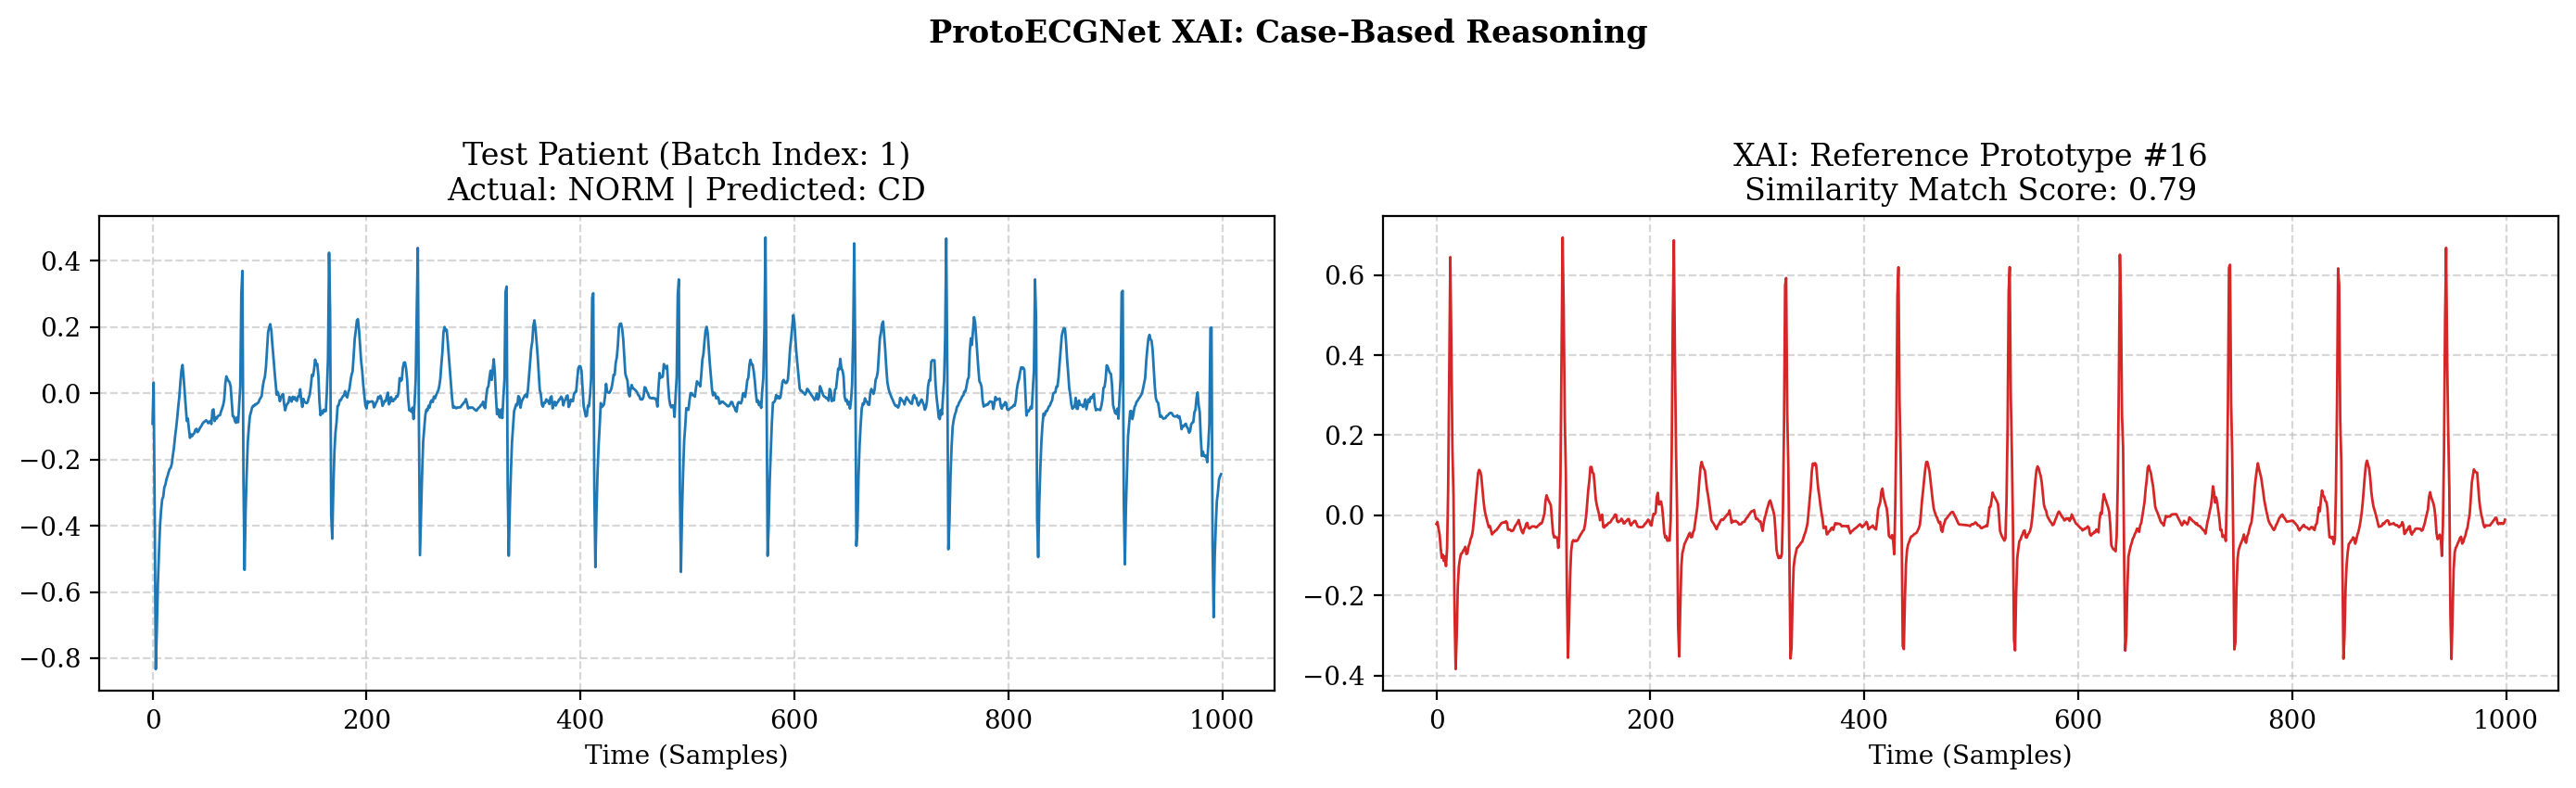

In [ ]:
plot_single_xai_case(
    model=model,
    inputs=xai_inputs,
    targets=xai_targets,
    sample_idx=1,
    projected_indices=projected_ids,
    original_X=X_tensor[train_mask],
    class_names=superclasses,
    device=device
)

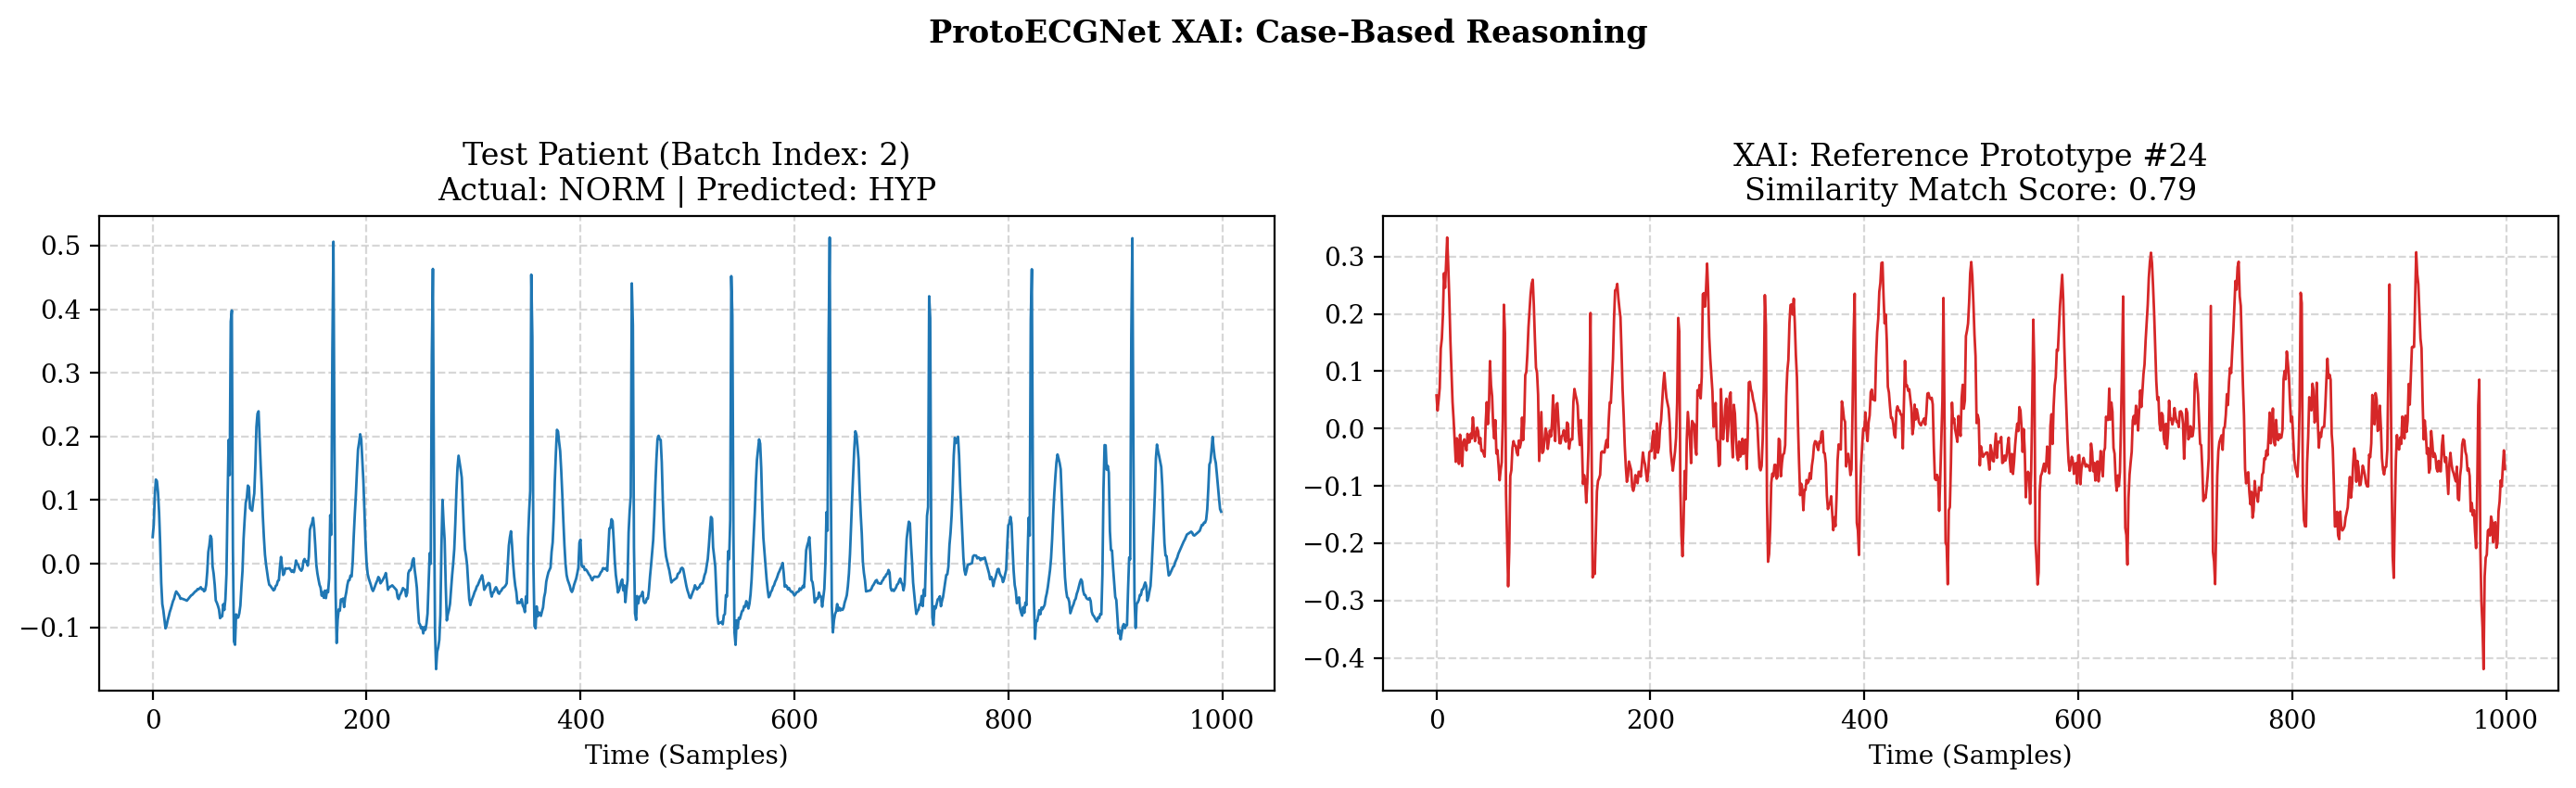

In [ ]:

plot_single_xai_case(
    model=model,
    inputs=xai_inputs,
    targets=xai_targets,
    sample_idx=2,
    projected_indices=projected_ids,
    original_X=X_tensor[train_mask],
    class_names=superclasses,
    device=device
)

# 4 XAI Techniques

In [ ]:
!pip install captum -q


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients, GradientShap, Saliency, Occlusion


class CaptumWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits, _ = self.model(x)
        return logits

captum_model = CaptumWrapper(model).to(device)
captum_model.eval()

inputs, targets = next(iter(test_loader))
xai_patient_idx = 1


test_ecg = inputs[xai_patient_idx].unsqueeze(0).to(device)
test_ecg.requires_grad = True
actual_targets = targets[xai_patient_idx].cpu().numpy()

with torch.no_grad():
    logits = captum_model(test_ecg)
    pred_class_idx = torch.argmax(logits, dim=1).item()

actual_classes = [superclasses[i] for i, val in enumerate(actual_targets) if val == 1.0]
print(f"--- XAI Target Selected ---")
print(f"Actual Disease(s): {', '.join(actual_classes) if actual_classes else 'None'}")
print(f"Model Prediction:  {superclasses[pred_class_idx]}")
print(f"Analyzing attributions for: {superclasses[pred_class_idx]}...")


lead_idx = 1
ecg_signal = test_ecg.squeeze(0).cpu().detach().numpy()[lead_idx]
time_steps = np.arange(1000)

--- XAI Target Selected ---
Actual Disease(s): NORM
Model Prediction:  CD
Analyzing attributions for: CD...


# 1-integrated gradient

Calculating Integrated Gradients...


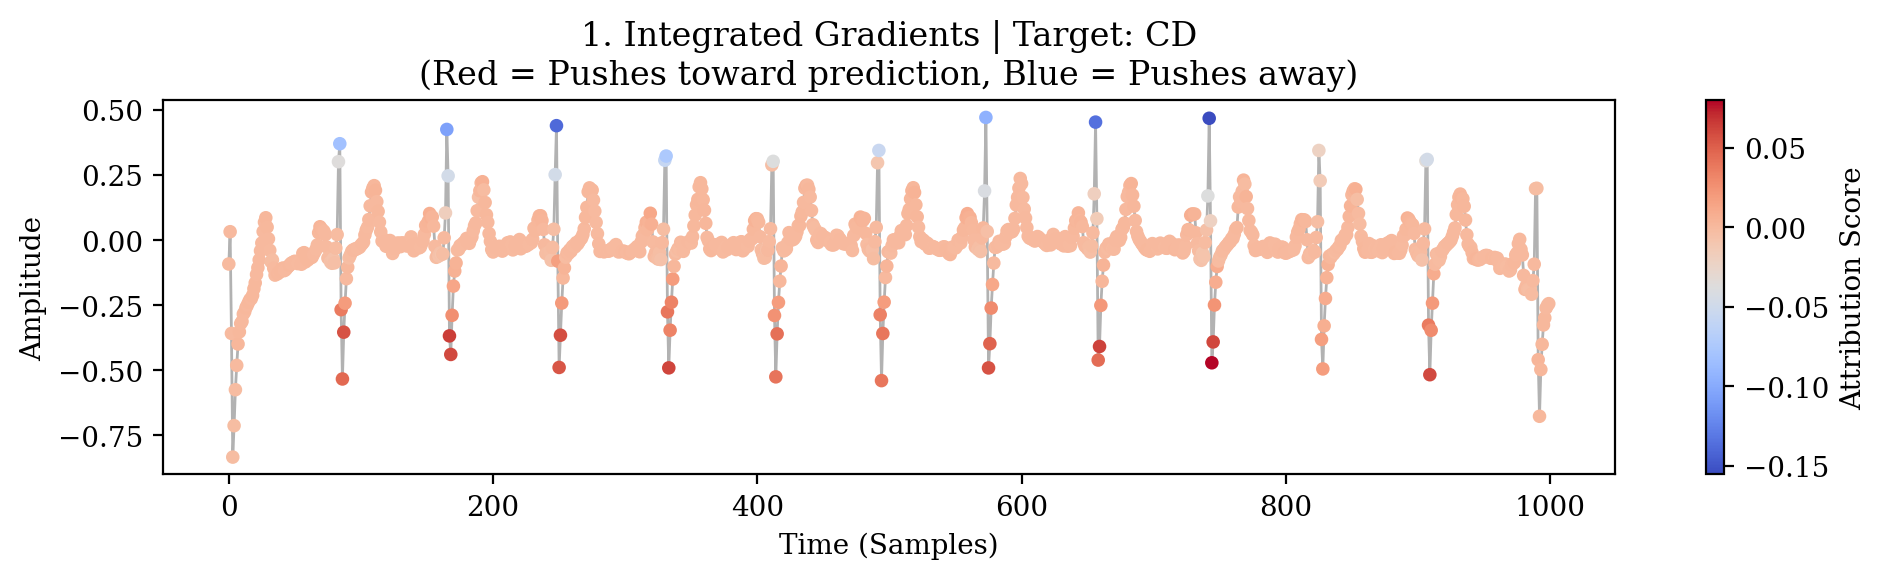

In [ ]:
print("Calculating Integrated Gradients...")
ig = IntegratedGradients(captum_model)
attr_ig, delta = ig.attribute(test_ecg, target=pred_class_idx, return_convergence_delta=True)
attr_ig = attr_ig.squeeze(0).cpu().detach().numpy()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_steps, ecg_signal, color='black', linewidth=1, alpha=0.3, label='ECG Signal')
sc = ax.scatter(time_steps, ecg_signal, c=attr_ig[lead_idx], cmap='coolwarm', s=15, zorder=5)

plt.colorbar(sc, ax=ax, label="Attribution Score")
ax.set_title(f"1. Integrated Gradients | Target: {superclasses[pred_class_idx]}\n(Red = Pushes toward prediction, Blue = Pushes away)")
ax.set_xlabel("Time (Samples)")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# 2-gradient shap

Calculating GradientSHAP...


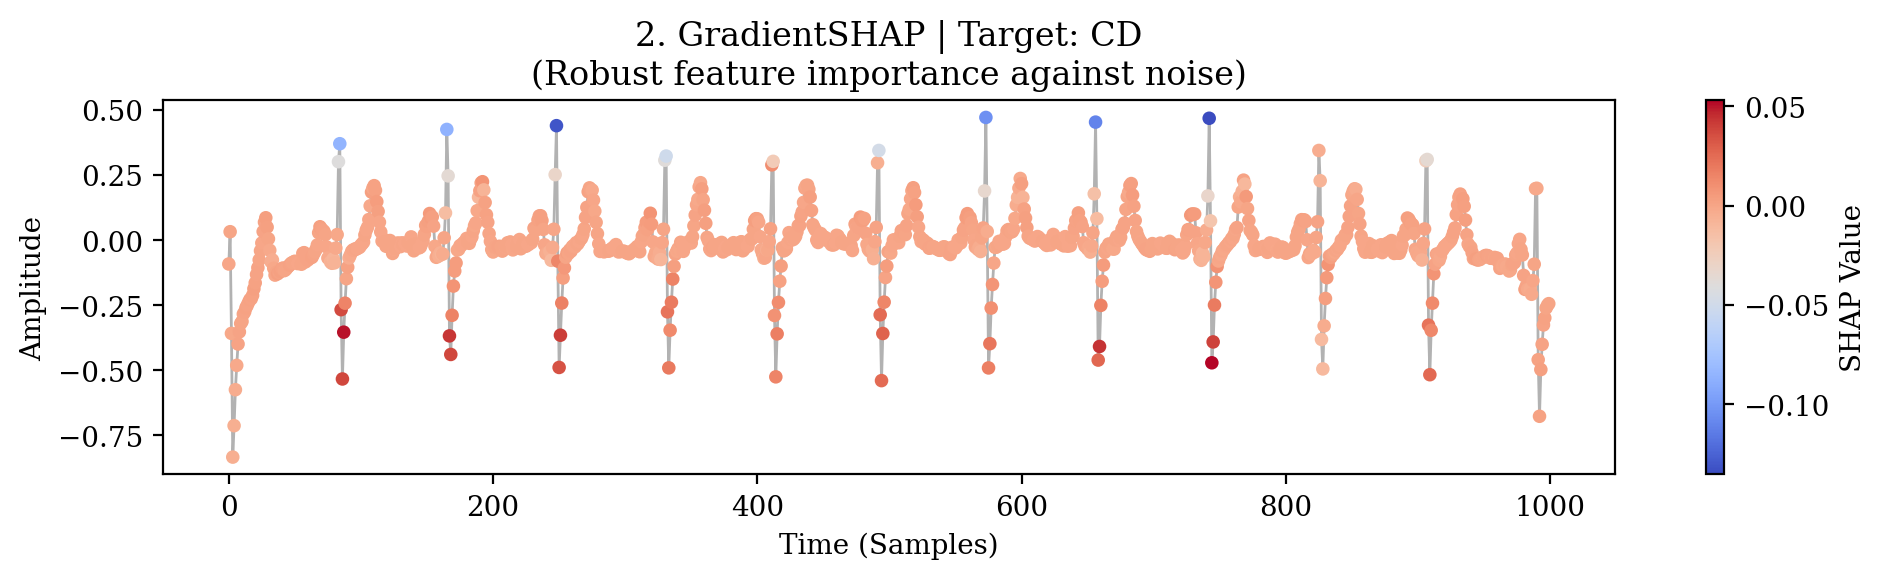

In [ ]:
print("Calculating GradientSHAP...")
background_baseline = torch.zeros((10, 12, 1000)).to(device)

gs = GradientShap(captum_model)
attr_gs = gs.attribute(test_ecg, baselines=background_baseline, target=pred_class_idx)
attr_gs = attr_gs.squeeze(0).cpu().detach().numpy()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_steps, ecg_signal, color='black', linewidth=1, alpha=0.3)
sc = ax.scatter(time_steps, ecg_signal, c=attr_gs[lead_idx], cmap='coolwarm', s=15, zorder=5)

plt.colorbar(sc, ax=ax, label="SHAP Value")
ax.set_title(f"2. GradientSHAP | Target: {superclasses[pred_class_idx]}\n(Robust feature importance against noise)")
ax.set_xlabel("Time (Samples)")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# 3-Saliency Map

Calculating Saliency Map...


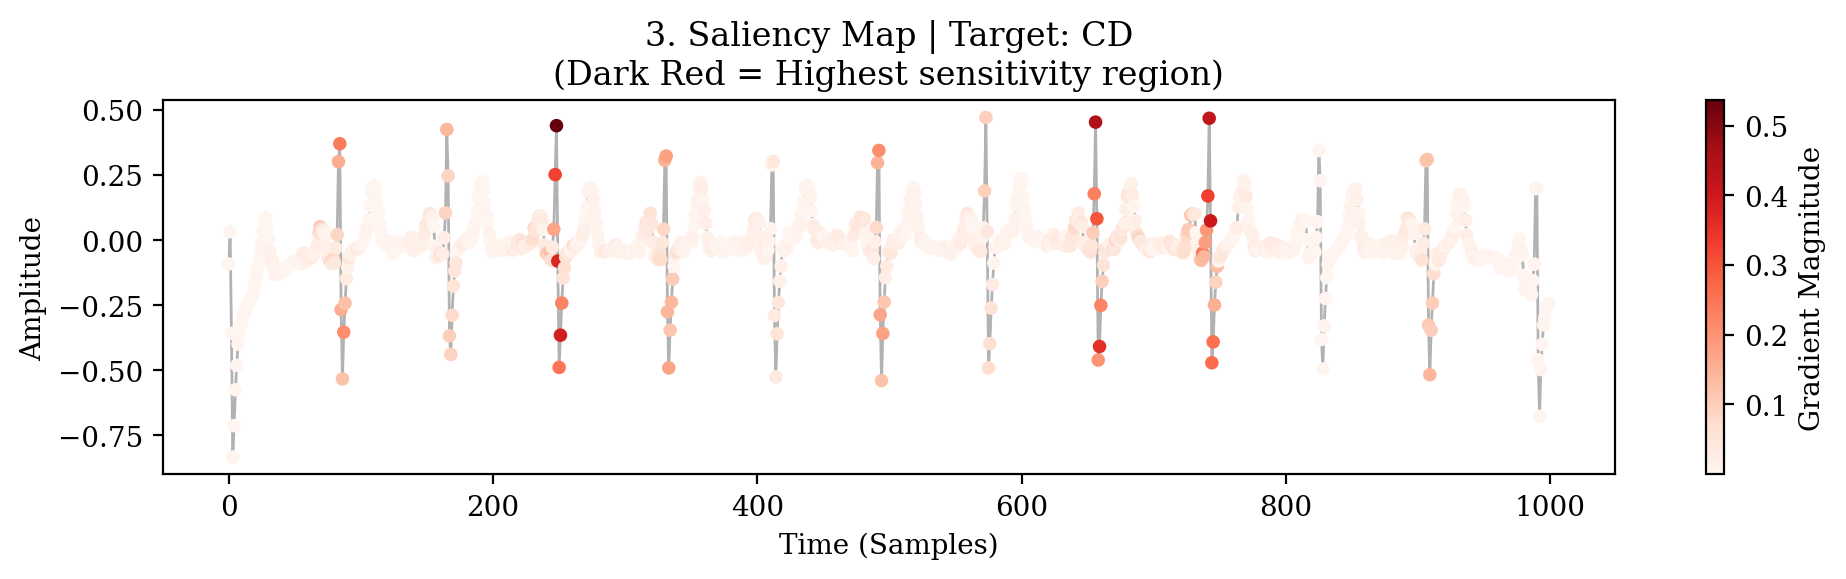

In [ ]:
print("Calculating Saliency Map...")
saliency = Saliency(captum_model)
attr_sal = saliency.attribute(test_ecg, target=pred_class_idx, abs=True)
attr_sal = attr_sal.squeeze(0).cpu().detach().numpy()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_steps, ecg_signal, color='black', linewidth=1, alpha=0.3)
sc = ax.scatter(time_steps, ecg_signal, c=attr_sal[lead_idx], cmap='Reds', s=15, zorder=5)

plt.colorbar(sc, ax=ax, label="Gradient Magnitude")
ax.set_title(f"3. Saliency Map | Target: {superclasses[pred_class_idx]}\n(Dark Red = Highest sensitivity region)")
ax.set_xlabel("Time (Samples)")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# 4-occlusion

Calculating Occlusion Sensitivity (This may take a few seconds)...


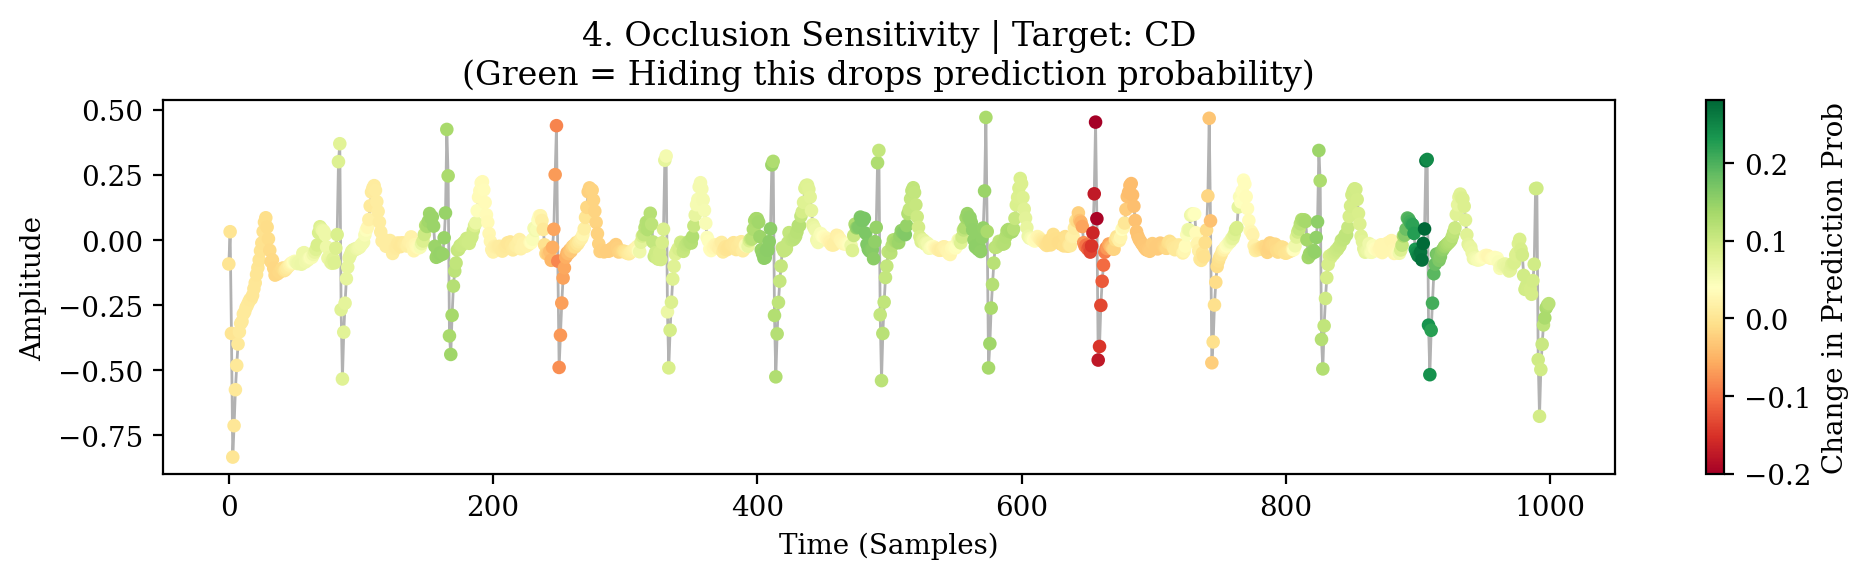

In [ ]:
print("Calculating Occlusion Sensitivity (This may take a few seconds)...")
occlusion = Occlusion(captum_model)
attr_occ = occlusion.attribute(test_ecg,
                               sliding_window_shapes=(12, 20),
                               target=pred_class_idx)
attr_occ = attr_occ.squeeze(0).cpu().detach().numpy()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_steps, ecg_signal, color='black', linewidth=1, alpha=0.3)
sc = ax.scatter(time_steps, ecg_signal, c=attr_occ[lead_idx], cmap='RdYlGn', s=15, zorder=5)

plt.colorbar(sc, ax=ax, label="Change in Prediction Prob")
ax.set_title(f"4. Occlusion Sensitivity | Target: {superclasses[pred_class_idx]}\n(Green = Hiding this drops prediction probability)")
ax.set_xlabel("Time (Samples)")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()